In [1]:
import numpy as np

In [2]:
class Value:
    def __init__(self, value, children = (), op = '', label = '', grad = 0):
        
        self.value = value
        self._prev = children
        self.grad = grad
        self._op = op
        self.label = label

    def __repr__(self):
        
        return f'Value <data = {self.value}>'

    def __add__(self, other):

        if isinstance(other, Value):
            new_val = other.value
        else:
            return NotImplemented
        
        return Value(new_val + self.value, (self, other), '+')

    def __mul__(self, other):
        
        if isinstance(other, Value):
            new_val = other.value
        else:
            return NotImplemented
        
        return Value(new_val * self.value, (self, other), '*')

In [3]:
a = Value(10, label = 'a')
b = Value(20, label = 'b')
c = a * b; c.label = 'c'

d = Value(30, label = 'd')
f = c + d; f.label = 'f'

g = Value(40, label = 'g')
L = g * f; L.label = 'L'

L

Value <data = 9200>

In [4]:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root, format='svg', rankdir='LR'):
    """
    format: png | svg | ...
    rankdir: TB (top to bottom graph) | LR (left to right)
    """
    assert rankdir in ['LR', 'TB']
    nodes, edges = trace(root)
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir}) #, node_attr={'rankdir': 'TB'})
    
    for n in nodes:
        dot.node(name=str(id(n)), label = "{ %s | value %.4f | grad %.2f }" % (n.label, n.value, n.grad), shape='record')
        if n._op:
            dot.node(name=str(id(n)) + n._op, label=n._op)
            dot.edge(str(id(n)) + n._op, str(id(n)))
    
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot

In [5]:
L.grad = 1 # dL/dL

"""
 L = f*g
 dL / df = g
 dL / dg = f
"""
g.grad = f.value
f.grad = g.value

"""
 dL / dc = (dL / df) * (df / dc)
         = g * 1 = g

 dL / dd = (dL / df) * (df / dd)
         = g * 1 = g
"""
c.grad = g.value
d.grad = g.value

"""
 dL / da = (dL / df) * (df / dc) * (dc / da)
         = g * 1 * b
         
 dL / db = (dL / df) * (df / dc) * (dc / db)
         = g * 1 * a
"""
a.grad = g.value * b.value
b.grad = g.value * a.value

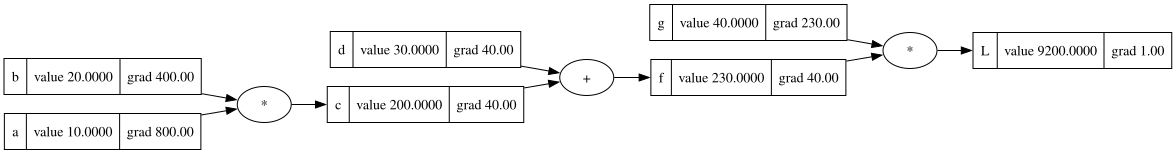

In [6]:
draw_dot(L)